# 03 — Exploratory Data Analysis
**Bluestock Fintech Capstone**

Covers:
1. Library imports & theme setup
2. Load all datasets
3. Fund Master — scheme landscape
4. NAV History — price trends & volatility
5. AUM — fund house growth
6. SIP Inflows — industry momentum
7. Category Inflows — flow heatmap
8. Folio Count — investor base growth
9. Scheme Performance — risk-return deep dive
10. Investor Transactions — behavioural patterns
11. Portfolio Holdings — sector concentration

---
## Cell 1 — Imports & Theme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
print("Libraries loaded ✅")

Libraries loaded ✅


---
## Cell 2 — Load Datasets

In [2]:
fund_master  = pd.read_csv("../data/raw/01_fund_master.csv", parse_dates=["launch_date"])
nav          = pd.read_csv("../data/processed/nav_history_clean.csv", parse_dates=["date"])
aum          = pd.read_csv("../data/raw/03_aum_by_fund_house.csv", parse_dates=["date"])
sip          = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv", parse_dates=["month"])
category     = pd.read_csv("../data/raw/05_category_inflows.csv", parse_dates=["month"])
folio        = pd.read_csv("../data/raw/06_industry_folio_count.csv", parse_dates=["month"])
performance  = pd.read_csv("../data/processed/performance_clean.csv", parse_dates=["launch_date"])
transactions = pd.read_csv("../data/processed/transactions_clean.csv", parse_dates=["transaction_date"])
holdings     = pd.read_csv("../data/raw/09_portfolio_holdings.csv", parse_dates=["portfolio_date"])

datasets = {
    "fund_master":  fund_master,
    "nav":          nav,
    "aum":          aum,
    "sip":          sip,
    "category":     category,
    "folio":        folio,
    "performance":  performance,
    "transactions": transactions,
    "holdings":     holdings,
}

print(f"{'Dataset':<14} {'Rows':>7} {'Cols':>5}")
print("-" * 30)
for name, df in datasets.items():
    print(f"{name:<14} {len(df):>7,} {df.shape[1]:>5}")

Dataset           Rows  Cols
------------------------------
fund_master         40    15
nav             46,000    10
aum                 90     5
sip                 48     6
category           144     3
folio               21     6
performance         40    27
transactions    32,778    23
holdings           322     8


---
## 3 — Fund Master: Scheme Landscape

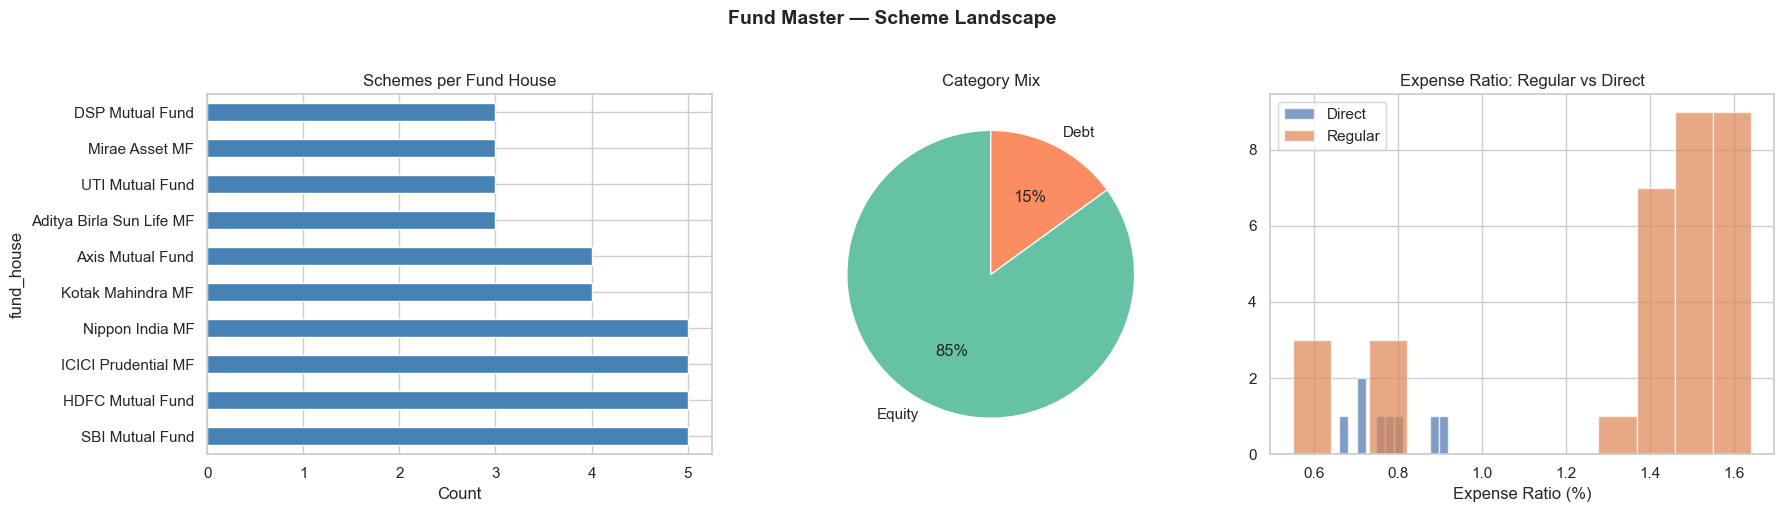

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. Schemes per fund house
fh_count = fund_master["fund_house"].value_counts()
fh_count.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Schemes per Fund House")
axes[0].set_xlabel("Count")

# 3b. Category distribution
fund_master["category"].value_counts().plot(
    kind="pie", ax=axes[1], autopct="%1.0f%%", startangle=90,
    colors=sns.color_palette("Set2")
)
axes[1].set_title("Category Mix")
axes[1].set_ylabel("")

# 3c. Expense ratio distribution — Regular vs Direct
for plan, grp in fund_master.groupby("plan"):
    axes[2].hist(grp["expense_ratio_pct"], bins=12, alpha=0.7, label=plan)
axes[2].set_title("Expense Ratio: Regular vs Direct")
axes[2].set_xlabel("Expense Ratio (%)")
axes[2].legend()

plt.suptitle("Fund Master — Scheme Landscape", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

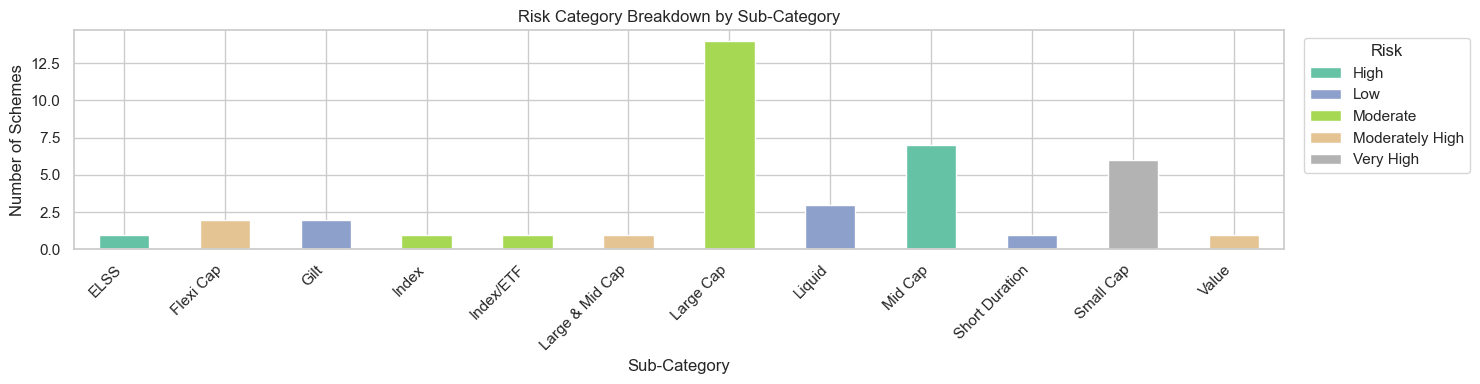

In [4]:
# Risk category breakdown by sub-category
risk_pivot = fund_master.groupby(["sub_category", "risk_category"]).size().unstack(fill_value=0)
risk_pivot.plot(kind="bar", stacked=True, figsize=(13, 4),
                colormap="Set2", edgecolor="white")
plt.title("Risk Category Breakdown by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Number of Schemes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Risk", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

---
## 4 — NAV History: Price Trends & Volatility

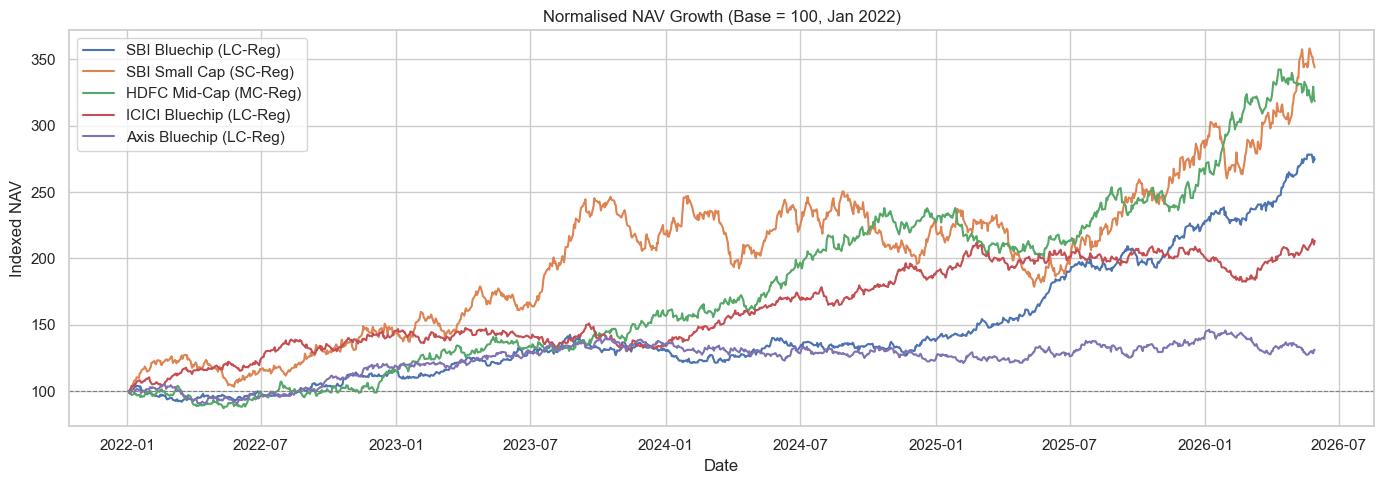

In [5]:
# 4a. Normalised NAV (Base 100) for selected schemes across cap sizes
sample = {
    119551: "SBI Bluechip (LC-Reg)",
    119598: "SBI Small Cap (SC-Reg)",
    100033: "HDFC Mid-Cap (MC-Reg)",
    120503: "ICICI Bluechip (LC-Reg)",
    119092: "Axis Bluechip (LC-Reg)",
}

fig, ax = plt.subplots(figsize=(14, 5))
for code, label in sample.items():
    s = nav[nav["amfi_code"] == code].sort_values("date")
    ax.plot(s["date"], s["nav"] / s["nav"].iloc[0] * 100, label=label)

ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Normalised NAV Growth (Base = 100, Jan 2022)")
ax.set_xlabel("Date"); ax.set_ylabel("Indexed NAV")
ax.legend()
plt.tight_layout()
plt.show()

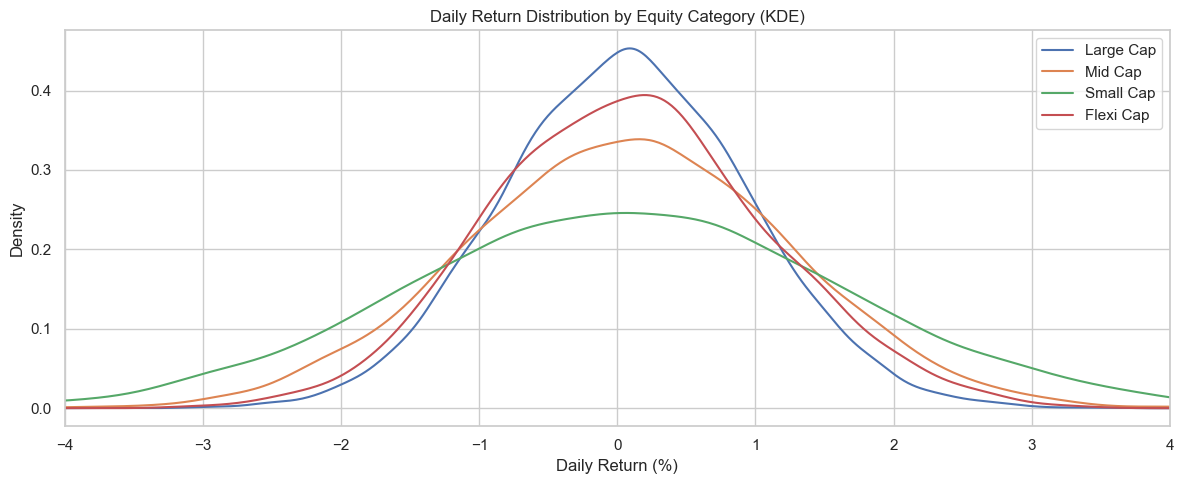

In [6]:
# 4b. Daily return distribution by category
nav_ret = nav.dropna(subset=["daily_return_pct"])
# Keep equity categories only for readability
eq_cats = ["Large Cap", "Mid Cap", "Small Cap", "Flexi Cap"]
nav_eq  = nav_ret[nav_ret["sub_category"].isin(eq_cats)]

fig, ax = plt.subplots(figsize=(12, 5))
for cat in eq_cats:
    subset = nav_eq[nav_eq["sub_category"] == cat]["daily_return_pct"]
    subset.plot(kind="kde", ax=ax, label=cat, linewidth=1.5)

ax.set_xlim(-4, 4)
ax.set_title("Daily Return Distribution by Equity Category (KDE)")
ax.set_xlabel("Daily Return (%)")
ax.legend()
plt.tight_layout()
plt.show()

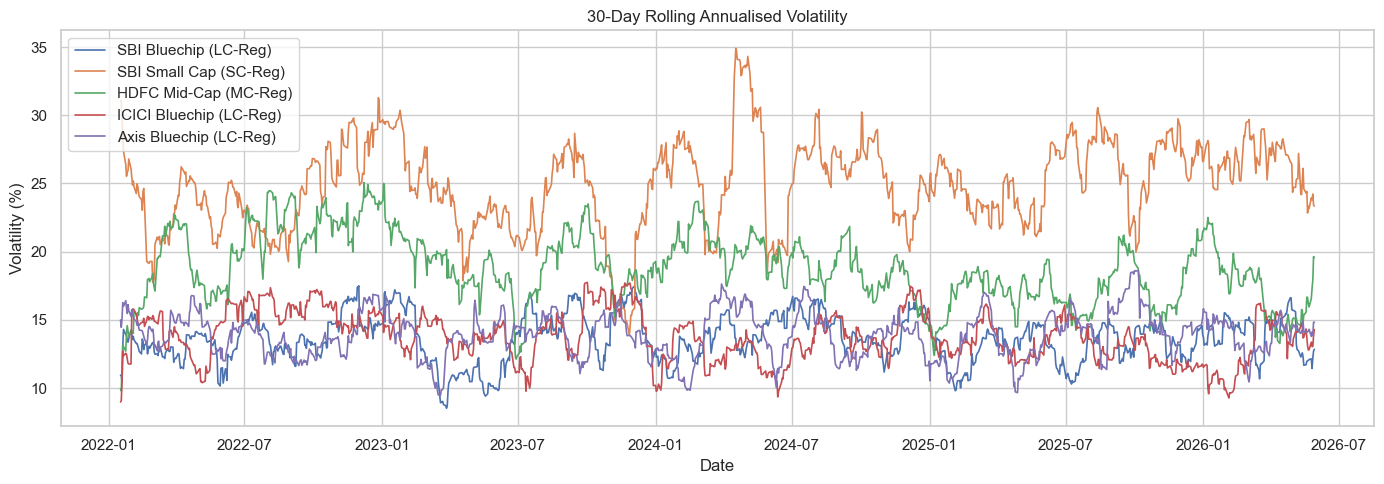

In [7]:
# 4c. 30-day rolling volatility for sample schemes
fig, ax = plt.subplots(figsize=(14, 5))
for code, label in sample.items():
    s = nav[nav["amfi_code"] == code].sort_values("date").dropna(subset=["rolling_vol_30d"])
    ax.plot(s["date"], s["rolling_vol_30d"], label=label, linewidth=1.2)

ax.set_title("30-Day Rolling Annualised Volatility")
ax.set_xlabel("Date"); ax.set_ylabel("Volatility (%)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# 4d. Interactive Plotly NAV chart
fig_px = px.line(
    nav[nav["amfi_code"].isin(sample.keys())],
    x="date", y="nav", color="scheme_name",
    title="NAV History — Interactive (Plotly)",
    labels={"nav": "NAV (₹)", "date": "Date", "scheme_name": "Scheme"},
    template="plotly_white"
)
fig_px.show()

---
## 5 — AUM: Fund House Growth

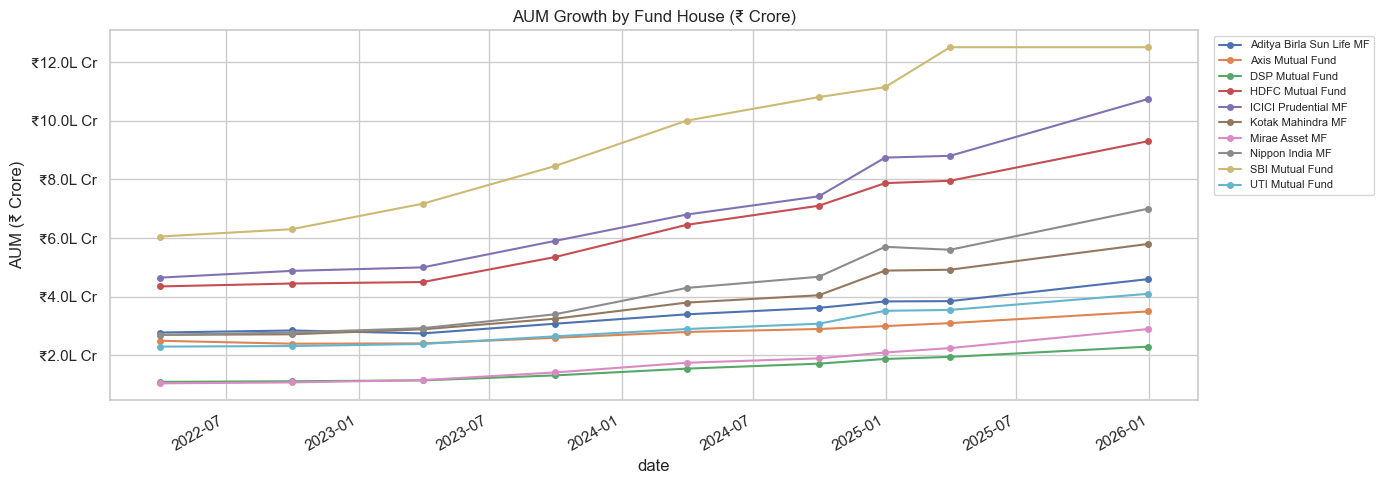

In [9]:
# 5a. AUM growth line chart
pivot_aum = aum.pivot_table(index="date", columns="fund_house", values="aum_crore")

fig, ax = plt.subplots(figsize=(14, 5))
pivot_aum.plot(ax=ax, marker="o", markersize=4)
ax.set_title("AUM Growth by Fund House (₹ Crore)")
ax.set_ylabel("AUM (₹ Crore)")
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e5:.1f}L Cr"))
plt.tight_layout()
plt.show()

In [10]:
# 5b. Latest AUM market share
latest_aum = aum[aum["date"] == aum["date"].max()].sort_values("aum_crore", ascending=False)

fig = px.pie(latest_aum, values="aum_crore", names="fund_house",
             title=f"AUM Market Share — {latest_aum['date'].iloc[0].date()}",
             hole=0.4, template="plotly_white")
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()

---
## 6 — SIP Inflows: Industry Momentum

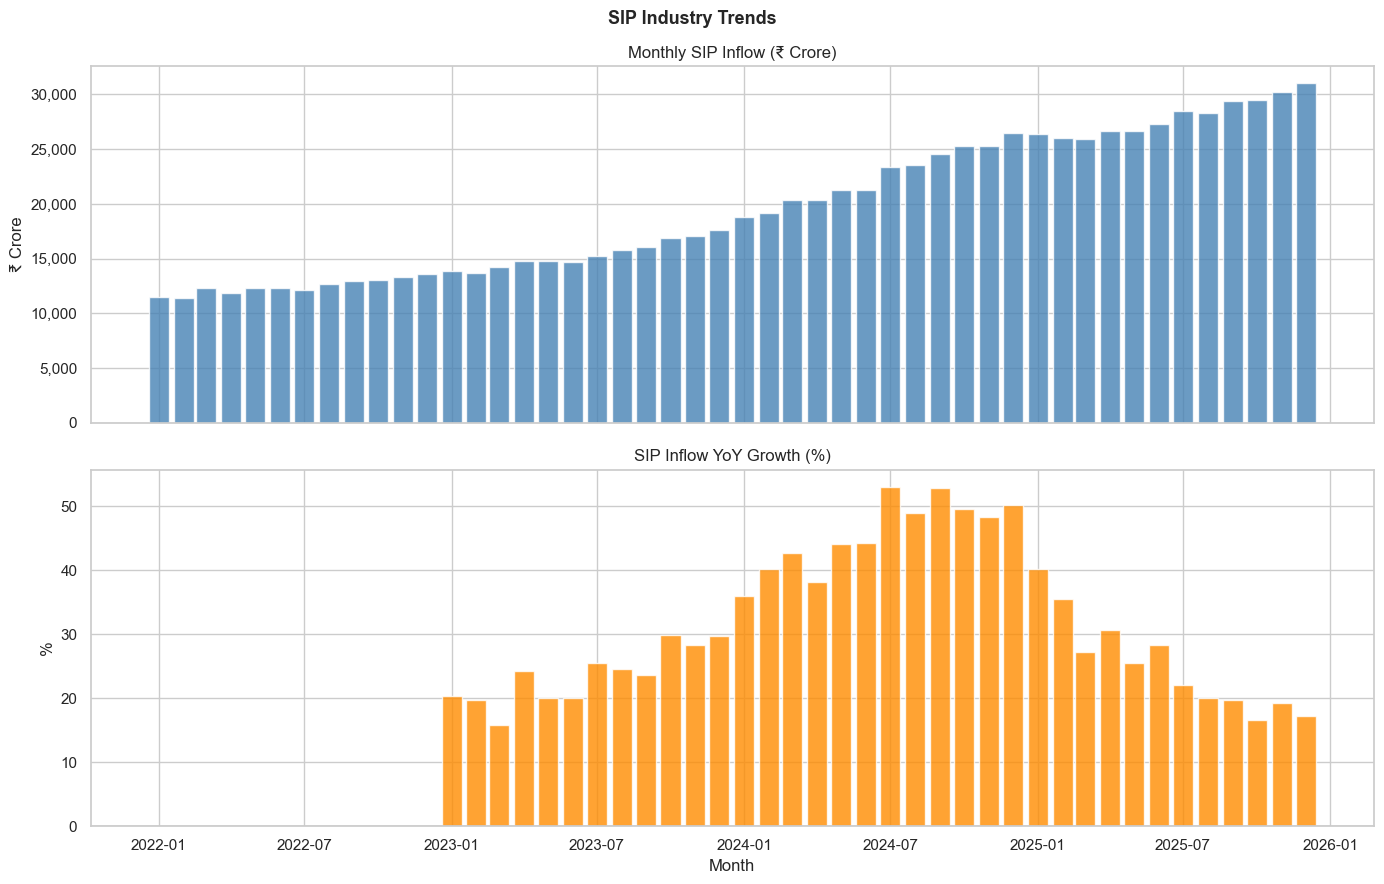

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# 6a. Monthly SIP inflow bar
axes[0].bar(sip["month"], sip["sip_inflow_crore"], width=25,
            color="steelblue", alpha=0.8)
axes[0].set_title("Monthly SIP Inflow (₹ Crore)")
axes[0].set_ylabel("₹ Crore")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# 6b. YoY growth
sip_yoy = sip.dropna(subset=["yoy_growth_pct"])
axes[1].bar(sip_yoy["month"], sip_yoy["yoy_growth_pct"], width=25,
            color="darkorange", alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("SIP Inflow YoY Growth (%)")
axes[1].set_ylabel("%")
axes[1].set_xlabel("Month")

plt.suptitle("SIP Industry Trends", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

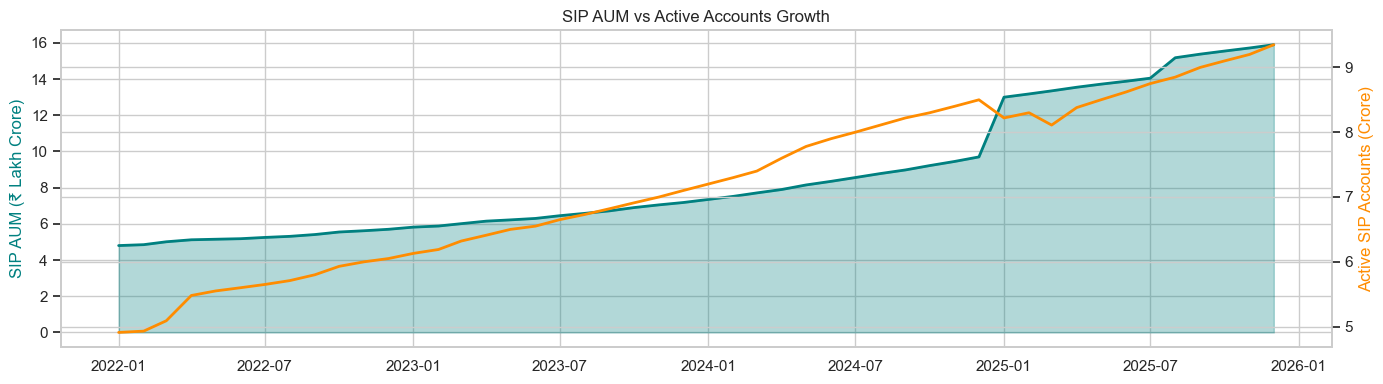

In [12]:
# 6c. SIP AUM vs Active Accounts dual-axis
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.fill_between(sip["month"], sip["sip_aum_lakh_crore"],
                 alpha=0.3, color="teal", label="SIP AUM (₹ L Cr)")
ax1.plot(sip["month"], sip["sip_aum_lakh_crore"], color="teal", linewidth=2)
ax1.set_ylabel("SIP AUM (₹ Lakh Crore)", color="teal")
ax2 = ax1.twinx()
ax2.plot(sip["month"], sip["active_sip_accounts_crore"],
         color="darkorange", linewidth=2, label="Active Accounts (Cr)")
ax2.set_ylabel("Active SIP Accounts (Crore)", color="darkorange")
ax1.set_title("SIP AUM vs Active Accounts Growth")
plt.tight_layout()
plt.show()

---
## 7 — Category Inflows: Flow Heatmap

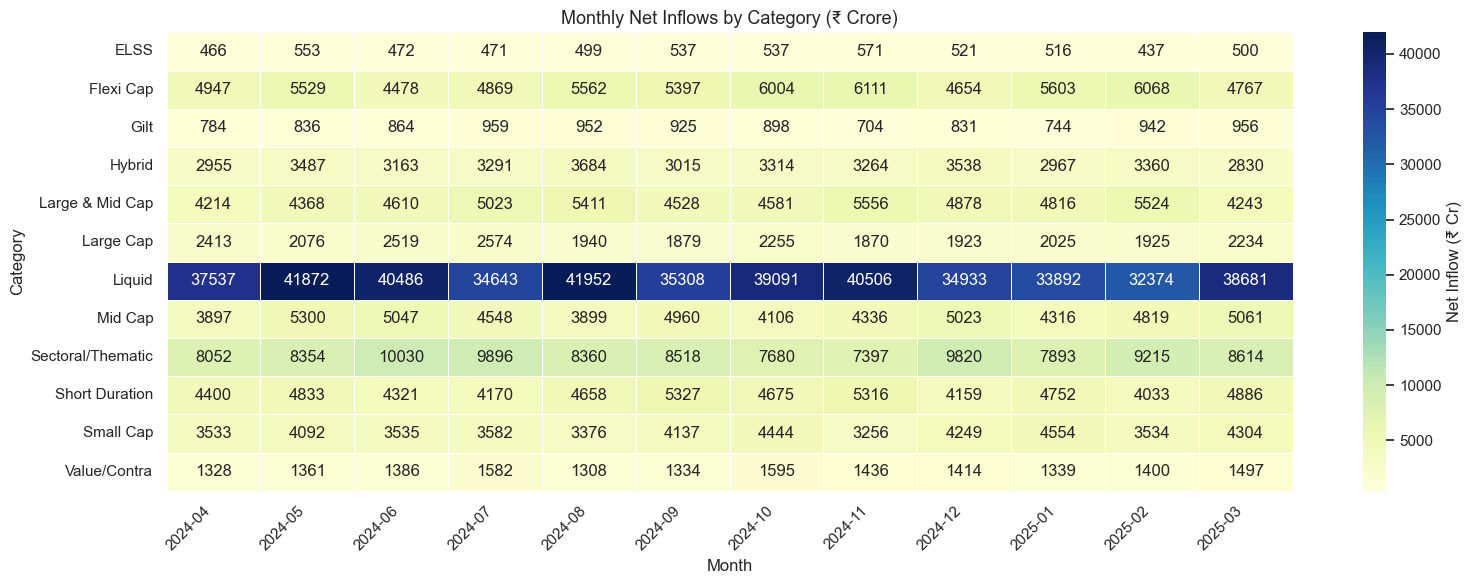

In [13]:
pivot_cat = category.pivot_table(
    index="category",
    columns=category["month"].dt.to_period("M").astype(str),
    values="net_inflow_crore"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_cat, annot=True, fmt=".0f", cmap="YlGnBu",
            linewidths=0.4, ax=ax,
            cbar_kws={"label": "Net Inflow (₹ Cr)"})
ax.set_title("Monthly Net Inflows by Category (₹ Crore)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

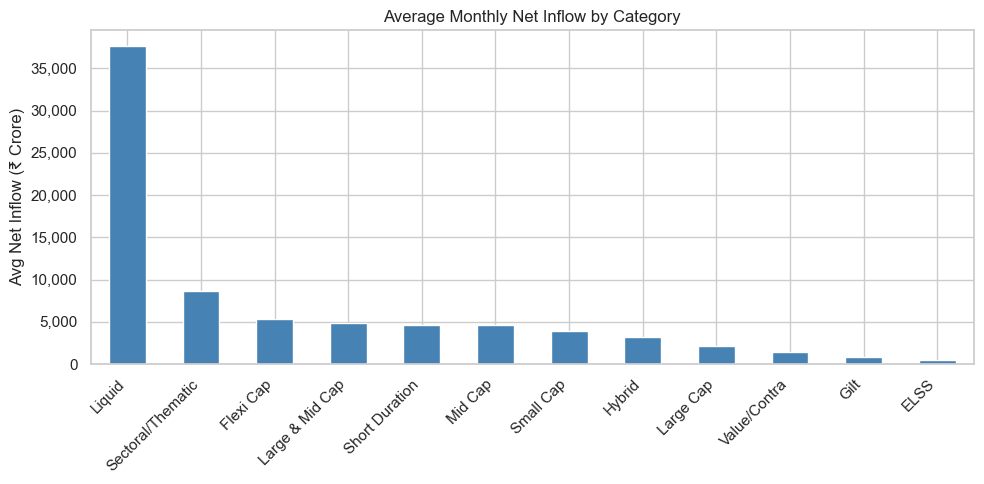

In [14]:
# Average inflow by category (bar)
cat_avg = category.groupby("category")["net_inflow_crore"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
cat_avg.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Average Monthly Net Inflow by Category")
ax.set_xlabel("")
ax.set_ylabel("Avg Net Inflow (₹ Crore)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 8 — Folio Count: Investor Base Growth

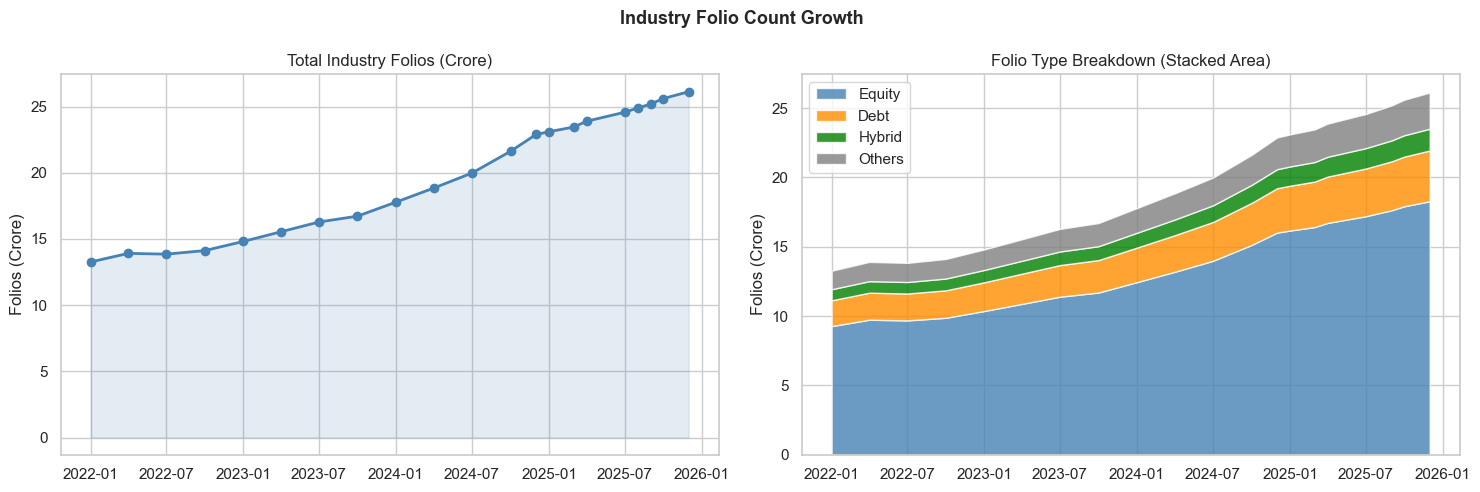

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 8a. Total folios growth
axes[0].plot(folio["month"], folio["total_folios_crore"],
             marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(folio["month"], folio["total_folios_crore"],
                     alpha=0.15, color="steelblue")
axes[0].set_title("Total Industry Folios (Crore)")
axes[0].set_ylabel("Folios (Crore)")

# 8b. Stacked area — folio type breakdown
folio_types = ["equity_folios_crore", "debt_folios_crore",
               "hybrid_folios_crore", "others_folios_crore"]
labels = ["Equity", "Debt", "Hybrid", "Others"]
colors = ["steelblue", "darkorange", "green", "gray"]
axes[1].stackplot(folio["month"],
                  [folio[col] for col in folio_types],
                  labels=labels, colors=colors, alpha=0.8)
axes[1].set_title("Folio Type Breakdown (Stacked Area)")
axes[1].set_ylabel("Folios (Crore)")
axes[1].legend(loc="upper left")

plt.suptitle("Industry Folio Count Growth", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9 — Scheme Performance: Risk-Return Deep Dive

In [16]:
# 9a. Risk vs Return scatter (Plotly — interactive)
fig_perf = px.scatter(
    performance,
    x="std_dev_ann_pct", y="return_3yr_pct",
    color="category", size="aum_crore",
    hover_data=["scheme_name", "fund_house", "sharpe_ratio",
                "expense_ratio_pct", "morningstar_rating"],
    title="Risk vs 3-Year Return (bubble size = AUM)",
    labels={"std_dev_ann_pct": "Annualised Std Dev (%)",
            "return_3yr_pct": "3-Year Return (%)"},
    template="plotly_white"
)
fig_perf.show()

C:\Users\chinm\AppData\Local\Temp\ipykernel_4408\1839966406.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="category", y="sharpe_ratio",


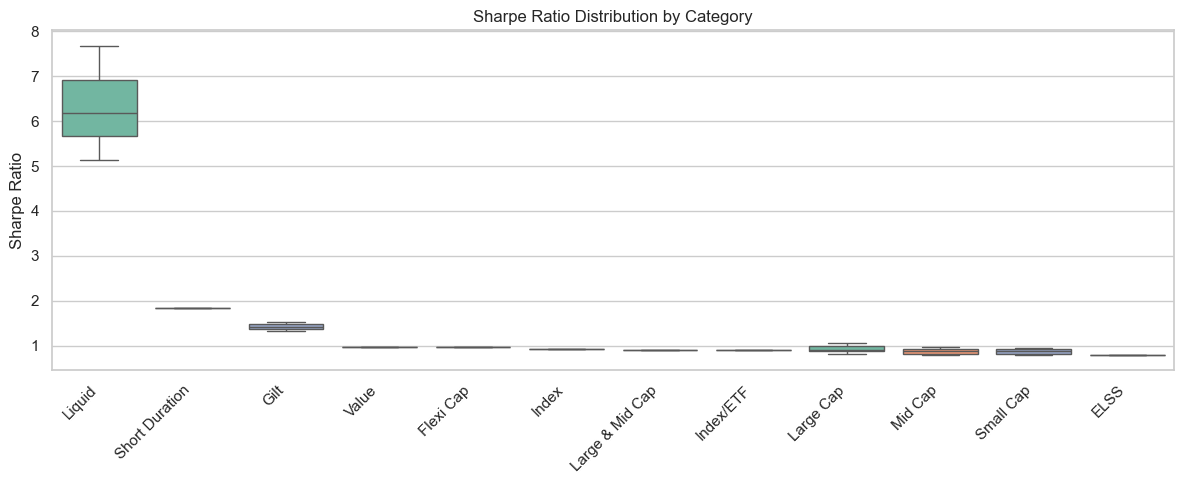

In [17]:
# 9b. Sharpe ratio by category — boxplot
fig, ax = plt.subplots(figsize=(12, 5))
order = performance.groupby("category")["sharpe_ratio"].median()\
               .sort_values(ascending=False).index
sns.boxplot(data=performance, x="category", y="sharpe_ratio",
            order=order, palette="Set2", ax=ax)
ax.set_title("Sharpe Ratio Distribution by Category")
ax.set_xlabel("")
ax.set_ylabel("Sharpe Ratio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

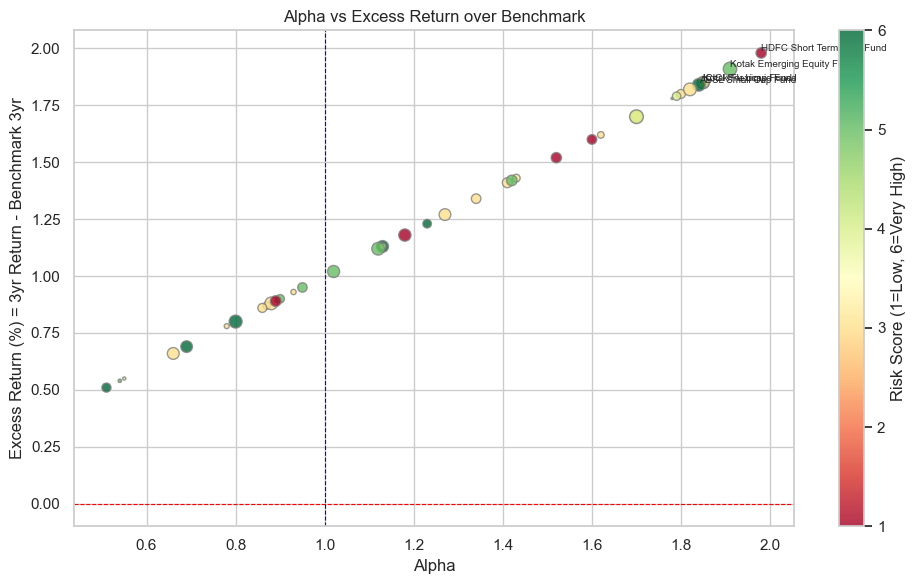

In [18]:
# 9c. Alpha vs Excess Return scatter
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(performance["alpha"], performance["excess_return"],
                c=performance["risk_score"], cmap="RdYlGn",
                s=performance["aum_crore"] / 500, alpha=0.8, edgecolors="gray")
plt.colorbar(sc, ax=ax, label="Risk Score (1=Low, 6=Very High)")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.axvline(1, color="blue", linestyle="--", linewidth=0.8)
ax.set_title("Alpha vs Excess Return over Benchmark")
ax.set_xlabel("Alpha")
ax.set_ylabel("Excess Return (%) = 3yr Return - Benchmark 3yr")
# Annotate top 5 by alpha
for _, row in performance.nlargest(5, "alpha").iterrows():
    ax.annotate(row["scheme_name"].split("-")[0].strip(),
                (row["alpha"], row["excess_return"]),
                fontsize=7, ha="left", va="bottom")
plt.tight_layout()
plt.show()

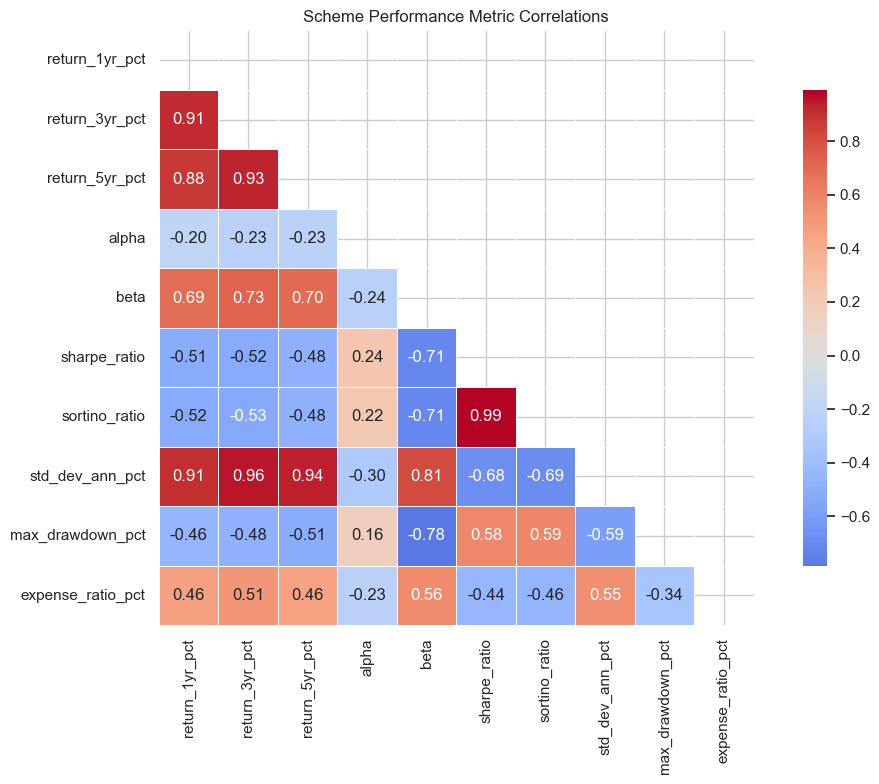

In [19]:
# 9d. Correlation heatmap of performance metrics
metric_cols = ["return_1yr_pct", "return_3yr_pct", "return_5yr_pct",
               "alpha", "beta", "sharpe_ratio", "sortino_ratio",
               "std_dev_ann_pct", "max_drawdown_pct", "expense_ratio_pct"]
corr = performance[metric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Scheme Performance Metric Correlations")
plt.tight_layout()
plt.show()

In [20]:
# 9e. Top 10 schemes by Sharpe Ratio
top10 = performance.nlargest(10, "sharpe_ratio")[
    ["scheme_name", "fund_house", "category", "sharpe_ratio",
     "return_3yr_pct", "std_dev_ann_pct", "alpha", "morningstar_rating"]
].reset_index(drop=True)
top10.index += 1
top10.style\
    .background_gradient(subset=["sharpe_ratio"], cmap="Greens")\
    .background_gradient(subset=["return_3yr_pct"], cmap="Blues")\
    .format({"sharpe_ratio": "{:.2f}", "return_3yr_pct": "{:.2f}%",
             "std_dev_ann_pct": "{:.1f}%", "alpha": "{:.2f}"})

,scheme_name,fund_house,category,sharpe_ratio,return_3yr_pct,std_dev_ann_pct,alpha,morningstar_rating
1,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,7.68,7.68%,0.5%,1.85,5
2,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,6.18,6.18%,0.5%,1.52,3
3,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,5.14,5.14%,0.5%,1.18,5
4,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,1.84,7.37%,4.0%,1.98,3
5,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,1.52,6.07%,4.0%,1.60,5
6,Nippon India Gilt Securities Fund - Regular - Growth,Nippon India MF,Gilt,1.33,5.31%,4.0%,0.89,4
7,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,1.06,14.84%,14.0%,0.78,5
8,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,1.06,14.81%,14.0%,1.62,5
9,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,1.03,14.41%,14.0%,0.88,3
10,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,1.00,14.00%,14.0%,0.86,4


---
## 10 — Investor Transactions: Behavioural Patterns

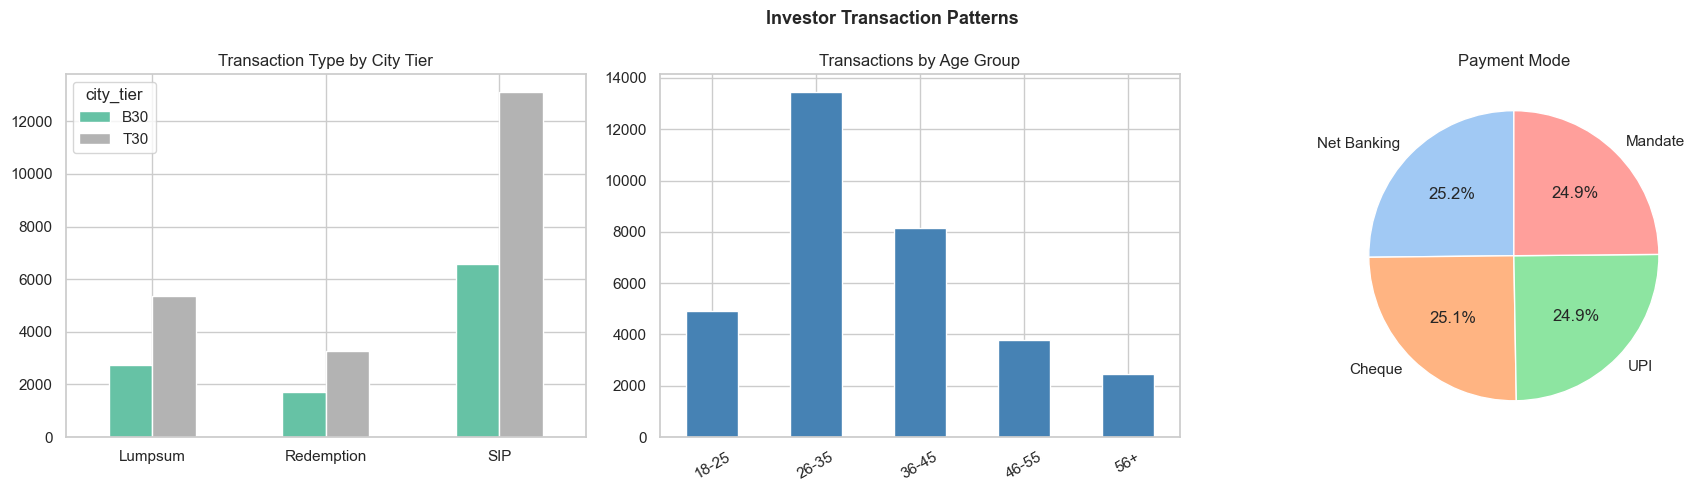

In [21]:
# 10a. Transaction type × City tier
txn_pivot = transactions.groupby(["transaction_type", "city_tier"]).size().unstack()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

txn_pivot.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Transaction Type by City Tier")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# 10b. Age group distribution
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
transactions["age_group"].value_counts().reindex(age_order).plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Transactions by Age Group")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

# 10c. Payment mode
transactions["payment_mode"].value_counts().plot(
    kind="pie", ax=axes[2], autopct="%1.1f%%", startangle=90,
    colors=sns.color_palette("pastel"))
axes[2].set_title("Payment Mode")
axes[2].set_ylabel("")

plt.suptitle("Investor Transaction Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

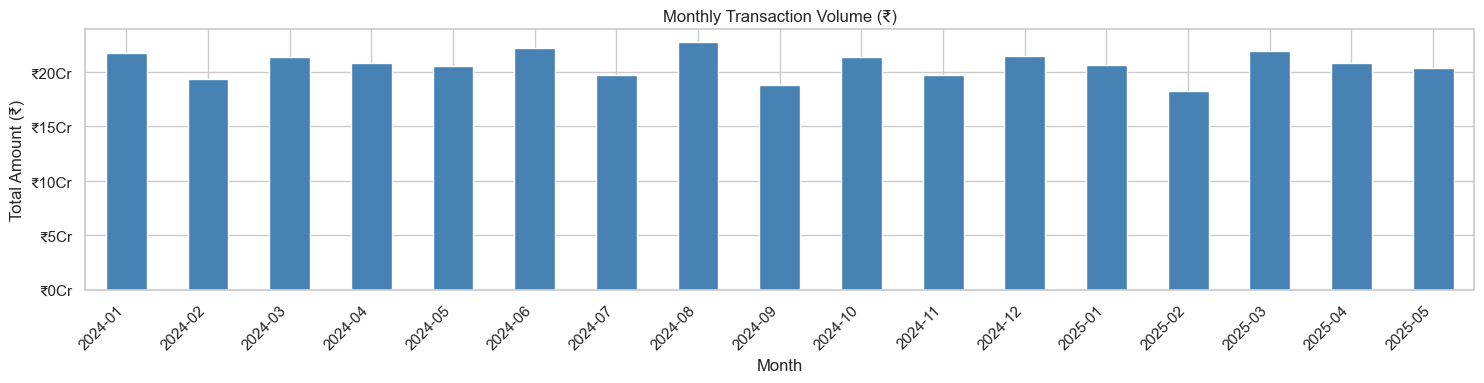

In [22]:
# 10d. Monthly transaction volume (₹)
monthly_vol = transactions.groupby("month_label")["amount_inr"].sum()

fig, ax = plt.subplots(figsize=(15, 4))
monthly_vol.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Monthly Transaction Volume (₹)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Amount (₹)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e7:.0f}Cr"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

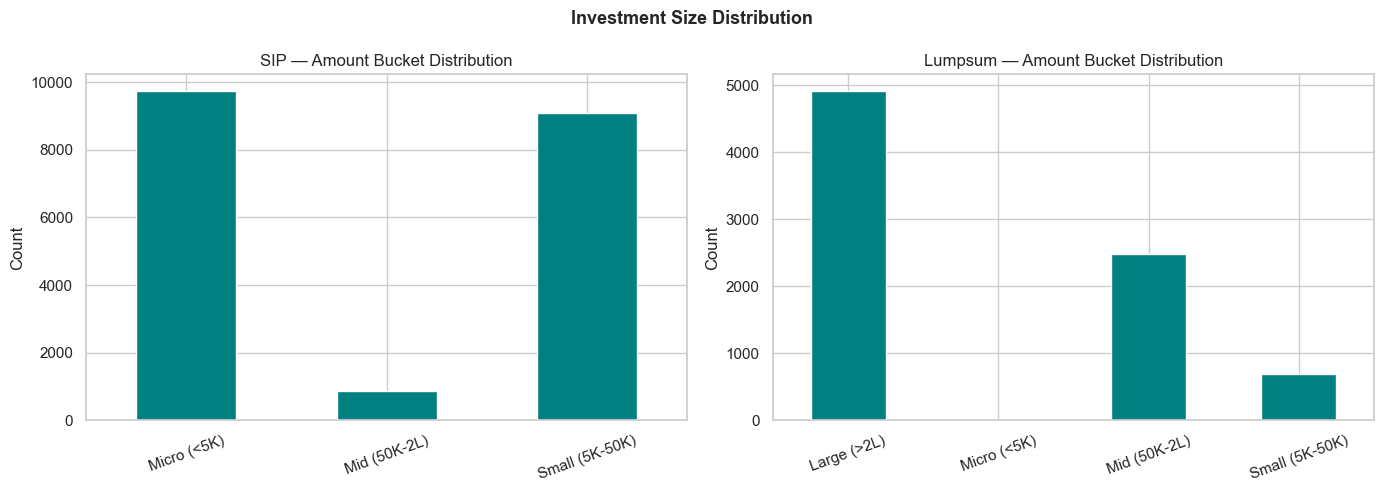

In [23]:
# 10e. Amount bucket distribution — SIP vs Lumpsum
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, txn_type in zip(axes, ["SIP", "Lumpsum"]):
    subset = transactions[transactions["transaction_type"] == txn_type]
    subset["amount_bucket"].value_counts().sort_index().plot(
        kind="bar", ax=ax, color="teal", edgecolor="white")
    ax.set_title(f"{txn_type} — Amount Bucket Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Investment Size Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

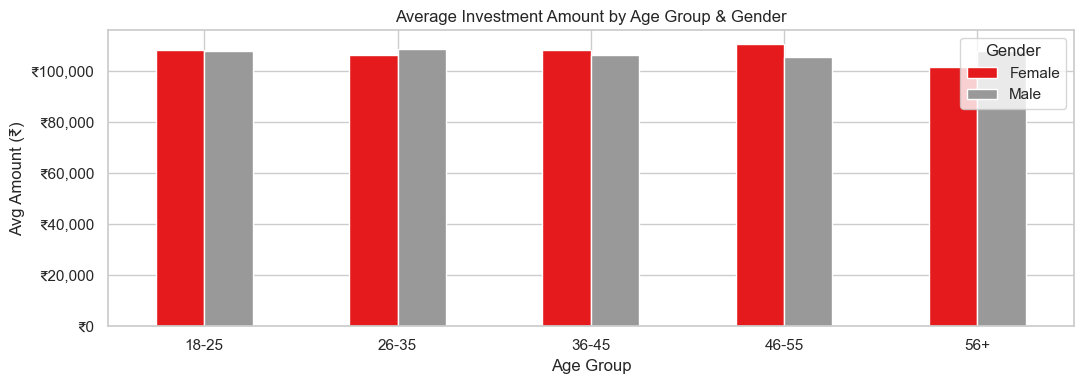

In [24]:
# 10f. Avg investment by gender × age group
gender_age = transactions.groupby(["gender", "age_group"])["amount_inr"].mean().unstack()
gender_age = gender_age[age_order]

gender_age.T.plot(kind="bar", figsize=(11, 4), colormap="Set1", edgecolor="white")
plt.title("Average Investment Amount by Age Group & Gender")
plt.xlabel("Age Group")
plt.ylabel("Avg Amount (₹)")
plt.yaxis = plt.gca().yaxis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [25]:
# 10g. Top 10 states by total investment
state_inv = transactions.groupby("state")["amount_inr"].sum().nlargest(10)

fig = px.bar(state_inv.reset_index(), x="state", y="amount_inr",
             title="Top 10 States by Total Investment Volume",
             labels={"amount_inr": "Total Investment (₹)", "state": "State"},
             color="amount_inr", color_continuous_scale="Blues",
             template="plotly_white")
fig.show()

---
## 11 — Portfolio Holdings: Sector Concentration

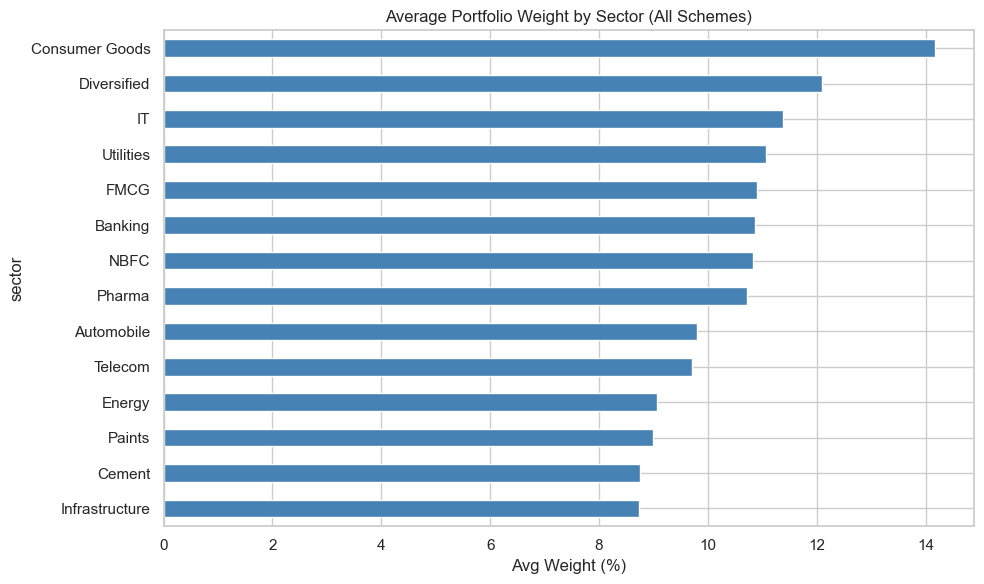

In [26]:
# 11a. Average portfolio weight by sector
sector_wt = holdings.groupby("sector")["weight_pct"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
sector_wt.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Average Portfolio Weight by Sector (All Schemes)")
ax.set_xlabel("Avg Weight (%)")
plt.tight_layout()
plt.show()

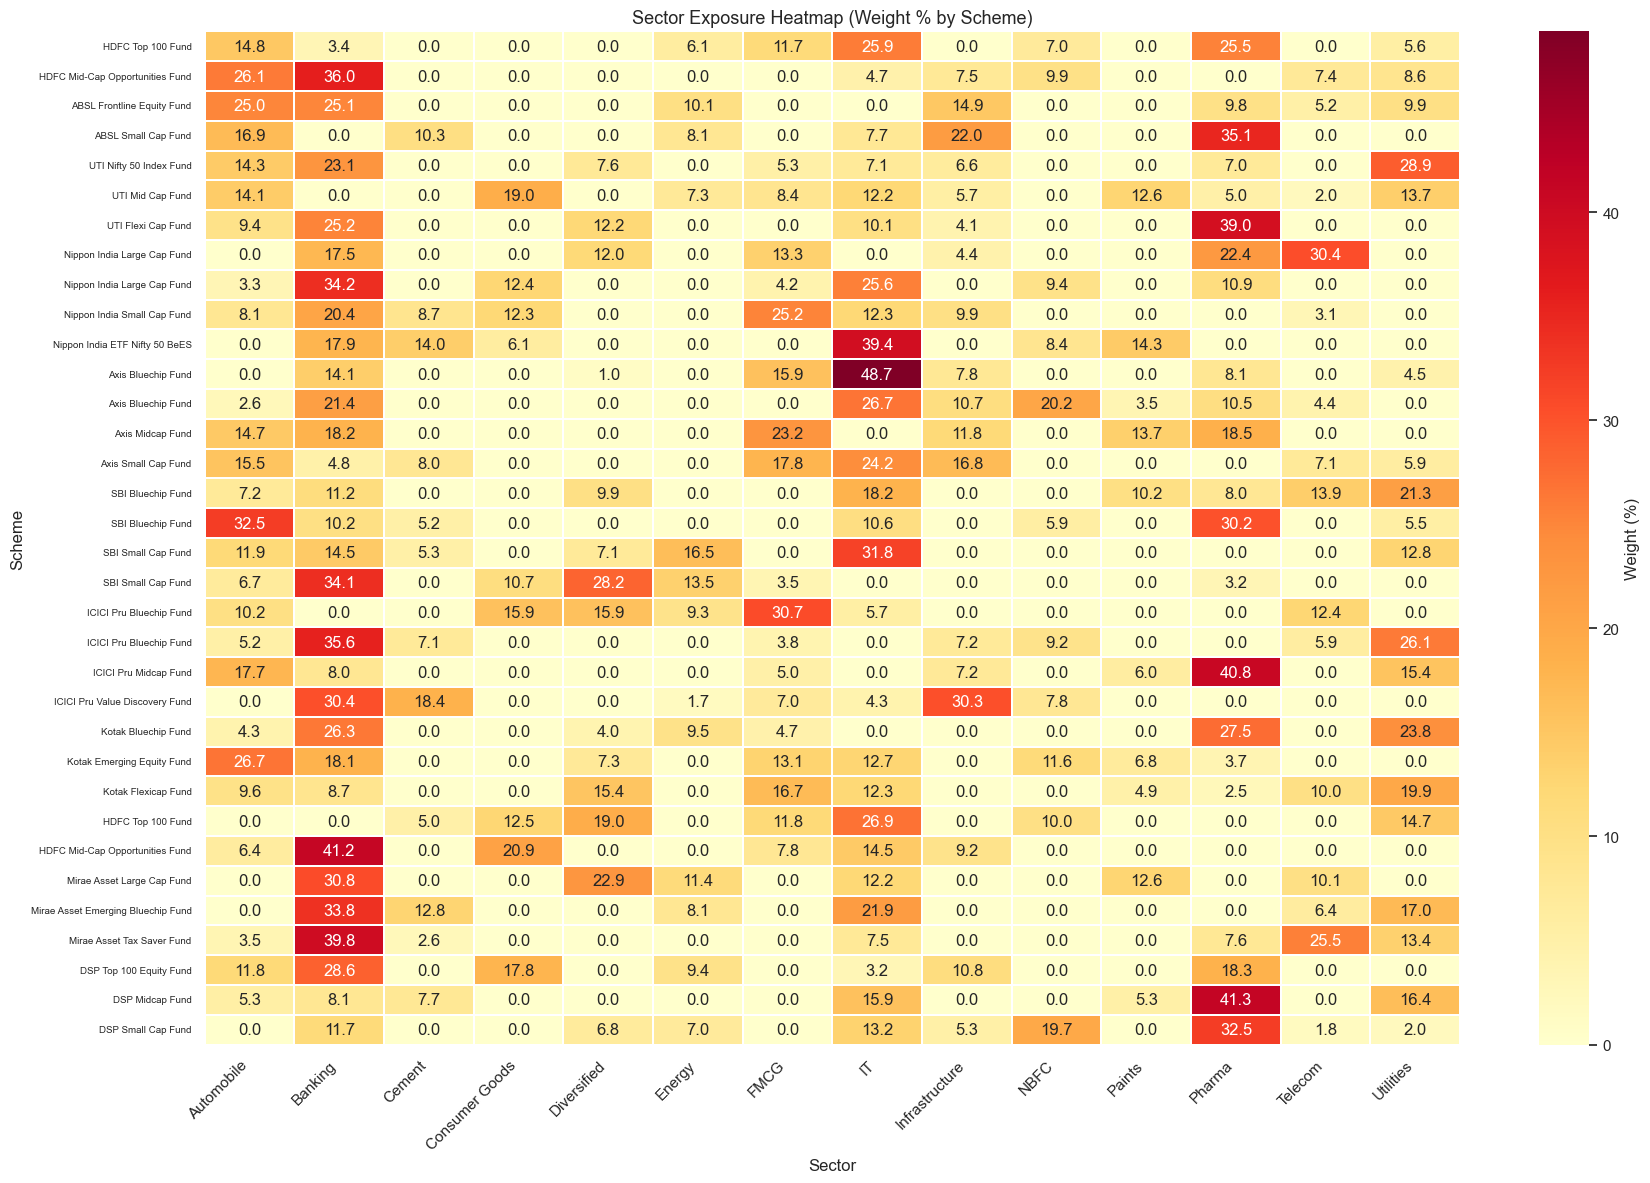

In [27]:
# 11b. Sector exposure heatmap (scheme × sector)
sec_pivot = holdings.pivot_table(
    index="amfi_code", columns="sector",
    values="weight_pct", aggfunc="sum", fill_value=0
)
# Add scheme name as label
sec_pivot.index = sec_pivot.index.map(
    fund_master.set_index("amfi_code")["scheme_name"]
    .str.split(" - ").str[0]
)

fig, ax = plt.subplots(figsize=(18, 12))
sns.heatmap(sec_pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.3, ax=ax,
            cbar_kws={"label": "Weight (%)"})
ax.set_title("Sector Exposure Heatmap (Weight % by Scheme)", fontsize=13)
ax.set_xlabel("Sector")
ax.set_ylabel("Scheme")
plt.xticks(rotation=45, ha="right")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [28]:
# 11c. Top 10 most held stocks across all schemes
top_stocks = holdings.groupby(["stock_symbol", "stock_name", "sector"])["weight_pct"]\
    .mean().reset_index().nlargest(10, "weight_pct")

fig = px.bar(top_stocks, x="stock_symbol", y="weight_pct", color="sector",
             text="weight_pct", hover_data=["stock_name"],
             title="Top 10 Most Heavily Weighted Stocks (Avg across schemes)",
             labels={"weight_pct": "Avg Weight (%)", "stock_symbol": "Stock"},
             template="plotly_white")
fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig.show()

---
## 12 — EDA Summary


In [29]:
print("=" * 60)
print("  EDA SUMMARY — BLUESTOCK CAPSTONE")
print("=" * 60)
print(f"  Fund houses tracked     : {fund_master['fund_house'].nunique()}")
print(f"  Total schemes           : {len(fund_master)}")
print(f"  NAV records             : {len(nav):,}")
print(f"  NAV date range          : {nav['date'].min().date()} → {nav['date'].max().date()}")
print(f"  Investor transactions   : {len(transactions):,}")
print(f"  Unique investors        : {transactions['investor_id'].nunique():,}")
print(f"  Total investment vol    : ₹{transactions['amount_inr'].sum()/1e9:.1f} Bn")
print(f"  Portfolio holdings      : {len(holdings)} (across {holdings['amfi_code'].nunique()} schemes)")
print(f"  Avg Sharpe ratio        : {performance['sharpe_ratio'].mean():.2f}")
print(f"  Avg 3yr return          : {performance['return_3yr_pct'].mean():.2f}%")
print(f"  Best performer (3yr)    : {performance.loc[performance['return_3yr_pct'].idxmax(), 'scheme_name']}")
print(f"  Best Sharpe             : {performance.loc[performance['sharpe_ratio'].idxmax(), 'scheme_name']}")
print("=" * 60)

  EDA SUMMARY — BLUESTOCK CAPSTONE
  Fund houses tracked     : 10
  Total schemes           : 40
  NAV records             : 46,000
  NAV date range          : 2022-01-03 → 2026-05-29
  Investor transactions   : 32,778
  Unique investors        : 5,000
  Total investment vol    : ₹3.5 Bn
  Portfolio holdings      : 322 (across 34 schemes)
  Avg Sharpe ratio        : 1.36
  Avg 3yr return          : 14.09%
  Best performer (3yr)    : SBI Small Cap Fund - Regular Plan - Growth
  Best Sharpe             : ICICI Pru Liquid Fund - Regular - Growth
